In [406]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [407]:
pd.set_option('display.max_columns', None)

In [408]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [409]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,independent,sector 4,3.25,14444.0,2250.0,Plot area 250(209.03 sq.m.),3,3,2,2.0,South-East,Old Property,NaN,2250.0,NaN,0,0,0,0,0,0,27,750.0
1,flat,bestech park view spa next,sector 67,2.70,11489.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3+,9.0,South-West,Moderately Old,2350.0,NaN,NaN,0,1,0,1,0,1,149,587.5
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,6228.0,Plot area 692(578.6 sq.m.),4,4,3+,2.0,North-East,New Property,NaN,6228.0,NaN,0,1,0,1,0,0,130,1557.0
3,flat,hcbs sports ville,sohna road,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,2,2,9.0,East,Undefined,NaN,750.0,650.0,0,0,0,0,0,0,0,375.0
4,flat,m3m skywalk,sector 74,1.78,12500.0,1424.0,Carpet area: 1424 (132.29 sq.m.),2,2,3+,12.0,NaN,Undefined,NaN,NaN,1424.0,0,0,0,0,0,0,63,712.0


In [410]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


## **Built up area**

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

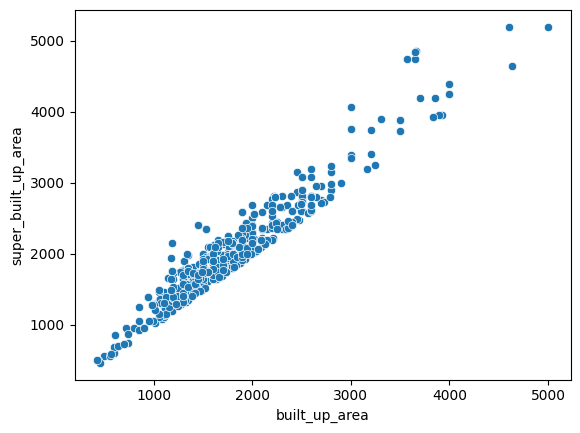

In [411]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

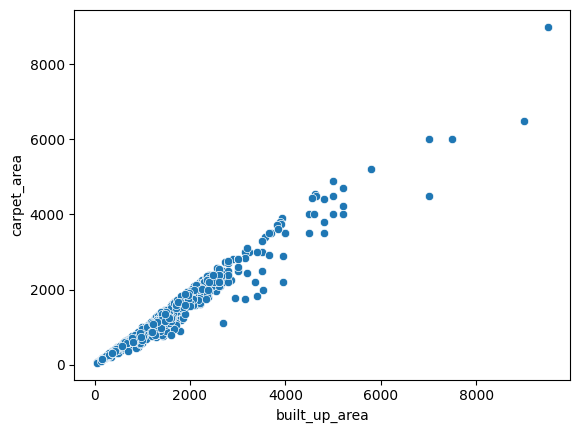

In [412]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [413]:
df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())].shape

(0, 24)

In [414]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [415]:
all_present_df.shape

(531, 24)

In [416]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [417]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [418]:
print(super_to_built_up_ratio,carpet_to_built_up_ratio)

1.105263157894737 0.9


In [419]:
# both present & built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [420]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
6,flat,alpha corp gurgaonone,sector 84,1.15,7497.0,1534.0,Super Built up area 1534(142.51 sq.m.)Carpet a...,2,2,3,14.0,South-East,Relatively New,1534.0,NaN,1260.0,1,0,0,0,0,0,28,767.0
17,flat,dlf regal gardens,sector 90,1.25,10417.0,1200.0,Super Built up area 1702(158.12 sq.m.)Carpet a...,3,3,3,18.0,North,Moderately Old,1702.0,NaN,1200.0,0,1,0,0,0,0,100,400.0
20,flat,shapoorji pallonji joyville gurugram,sector 102,1.75,15514.0,1128.0,Super Built up area 1852(172.06 sq.m.)Carpet a...,3,3,3+,1.0,East,Relatively New,1852.0,NaN,1128.0,0,0,0,0,0,0,49,376.0
55,flat,pivotal devaan,sector 84,0.34,5832.0,583.0,Super Built up area 583(54.16 sq.m.)Carpet are...,2,2,1,3.0,East,Relatively New,583.0,NaN,484.0,0,0,1,0,0,0,75,291.5
60,flat,ashiana anmol,sohna road,0.90,9464.0,951.0,Super Built up area 1275(118.45 sq.m.)Carpet a...,2,2,2,13.0,South,Relatively New,1275.0,NaN,951.0,0,0,0,0,0,2,120,475.5


In [421]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

/tmp/ipykernel_1009/1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
/tmp/ipykernel_1009/1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_bu

In [422]:
df.update(sbc_df)

In [423]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [424]:
# sb present c is null built up is null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [425]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,bestech park view spa next,sector 67,2.70,11489.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3+,9.0,South-West,Moderately Old,2350.0,NaN,NaN,0,1,0,1,0,1,149,587.500000
11,flat,sobha city,sector 108,3.35,13267.0,2525.0,Super Built up area 2072.9(192.58 sq.m.),3,4,2,19.0,NaN,New Property,2072.9,NaN,NaN,0,0,0,0,0,0,102,841.666667
21,flat,godrej,sector 79,1.29,8206.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,4.0,NaN,New Property,1572.0,NaN,NaN,0,0,0,0,0,0,0,786.000000
23,flat,ats triumph,sector 104,2.65,8413.0,3150.0,Super Built up area 3150(292.64 sq.m.),4,4,3+,10.0,North-East,Relatively New,3150.0,NaN,NaN,0,1,0,0,0,0,174,787.500000
25,flat,sbtl caladium,sector 109,1.88,6154.0,3055.0,Super Built up area 3055(283.82 sq.m.),4,5,3,10.0,North-East,Relatively New,3055.0,NaN,NaN,0,0,0,0,0,0,110,763.750000


In [426]:
sb_df['built_up_area'].fillna(round((sb_df['super_built_up_area']/1.105)),inplace=True)

/tmp/ipykernel_1009/4196656959.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round((sb_df['super_built_up_area']/1.105)),inplace=True)
/tmp/ipykernel_1009/4196656959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round((sb_df['super_built_up_area']/1.105)),inplace=True)


In [427]:
df.update(sb_df)

In [428]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [429]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [430]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
4,flat,m3m skywalk,sector 74,1.78,12500.0,1424.0,Carpet area: 1424 (132.29 sq.m.),2,2,3+,12.0,NaN,Undefined,NaN,NaN,1424.000000,0,0,0,0,0,0,63,712.000000
7,house,independent,sector 70a,2.10,3889.0,5400.0,Carpet area: 600 (55.74 sq.m.),3,2,1,3.0,NaN,New Property,NaN,NaN,600.000000,0,0,0,0,0,0,0,1800.000000
9,flat,mapsko mount ville,sector 79,1.40,9396.0,1490.0,Carpet area: 1490 (138.43 sq.m.),3,3,3,2.0,North,New Property,NaN,NaN,1490.000000,0,0,0,0,0,1,112,496.666667
10,flat,pyramid elite,sector 86,0.45,7745.0,581.0,Carpet area: 581.41 (54.01 sq.m.),2,2,1,4.0,NaN,Under Construction,NaN,NaN,581.358239,0,0,0,0,0,0,66,290.500000
15,flat,godrej oasis,sector 88a,1.30,7259.0,1791.0,Carpet area: 1791 (166.39 sq.m.),3,3,3+,4.0,North-West,Relatively New,NaN,NaN,1791.000000,0,0,0,0,0,0,79,597.000000


In [431]:
c_df['built_up_area'].fillna(round((c_df['carpet_area']/0.9)),inplace=True)

/tmp/ipykernel_1009/4289020208.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round((c_df['carpet_area']/0.9)),inplace=True)
/tmp/ipykernel_1009/4289020208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round((c_df['carpet_area']/0.9)),inplace=True)


In [432]:
df.update(c_df)

In [433]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


<Axes: xlabel='built_up_area', ylabel='price'>

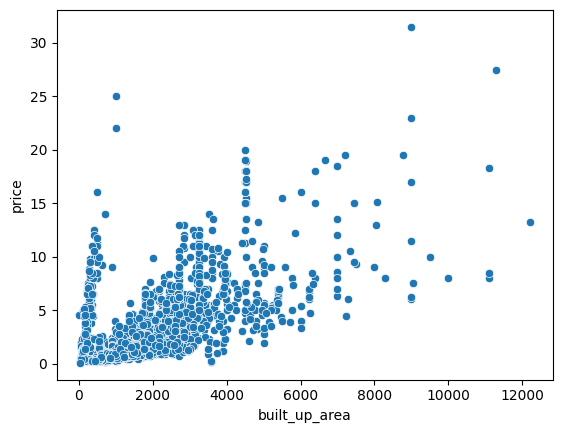

In [434]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [435]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [436]:
anamoly_df.sample(5)

,price,area,built_up_area
1173,8.80,2115.0,267.0
211,11.30,4500.0,480.0
361,4.85,1875.0,1697.0
3062,3.00,1557.0,1557.0
118,6.00,1710.0,1778.0


In [437]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [438]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

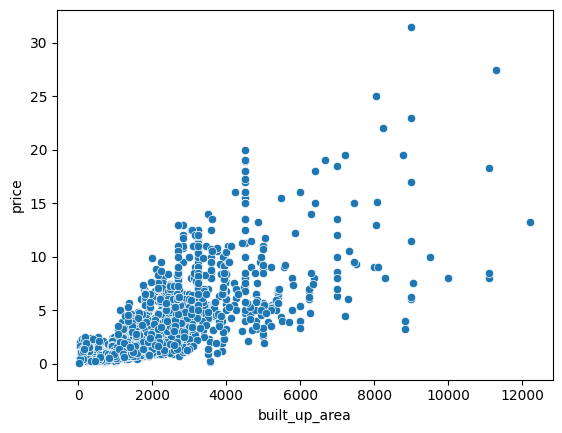

In [439]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [440]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [441]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,3,3,2,2.0,South-East,Old Property,2250.0,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,4,4,3+,9.0,South-West,Moderately Old,2127.0,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,4,4,3+,2.0,North-East,New Property,6228.0,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,2,2,2,9.0,East,Undefined,750.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,2,2,3+,12.0,NaN,Undefined,1582.0,0,0,0,0,0,0,63


In [442]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,17
facing,1011


## **floorNum**

In [443]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
54,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59
409,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,0,0
584,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,0,88
809,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
931,flat,experion heartsong,sector 108,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
1179,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,0,0
1215,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
1295,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
1918,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,0,0
1919,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,0,0


In [444]:
df[df['property_type']=='house']['floorNum'].median()

2.0

In [445]:
df['floorNum'].fillna(2.0,inplace=True)

/tmp/ipykernel_1009/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [446]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
facing,1011


## **facing**

<Axes: ylabel='count'>

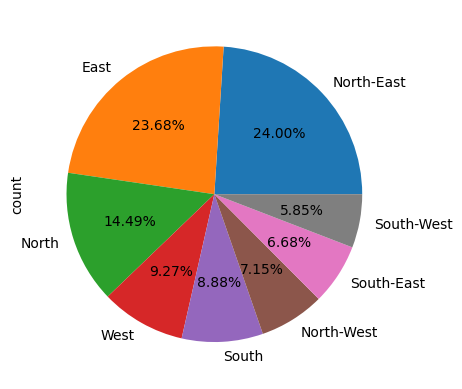

In [447]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [448]:
df.drop(columns=['facing'],inplace=True)

In [449]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,3,3,2,2.0,Old Property,2250.0,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,4,4,3+,9.0,Moderately Old,2127.0,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,4,4,3+,2.0,New Property,6228.0,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,2,2,2,9.0,Undefined,750.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,2,2,3+,12.0,Undefined,1582.0,0,0,0,0,0,0,63


In [450]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


## **agePossession**

In [451]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1605
New Property,557
Moderately Old,545
Old Property,293
Undefined,293
Under Construction,264


In [452]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3,flat,hcbs sports ville,sohna road,0.38,5067.0,2,2,2,9.0,Undefined,750.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,2,2,3+,12.0,Undefined,1582.0,0,0,0,0,0,0,63
22,flat,tulip petals,sector 89,1.10,7097.0,3,2,3,4.0,Undefined,1550.0,0,0,0,0,0,0,0
32,house,independent,sector 110,0.34,6800.0,1,1,0,1.0,Undefined,500.0,0,0,0,0,0,0,0
57,flat,signature global orchard avenue,sector 93,0.85,14238.0,2,2,0,10.0,Undefined,597.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3501,flat,signature global park,sector 36,0.87,7190.0,3,2,3,4.0,Undefined,1210.0,0,0,0,0,0,0,58
3503,flat,supertech araville,sector 79,0.90,6950.0,2,2,0,12.0,Undefined,1295.0,0,0,0,0,0,0,0
3528,flat,m3m capital,sector 113,1.83,13969.0,2,2,0,7.0,Undefined,1310.0,0,0,0,0,0,0,68
3532,flat,pivotal devaan apartments,sector 84,0.39,6500.0,2,2,0,5.0,Undefined,549.0,0,0,0,0,0,0,0


In [454]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        return mode_value[0]
        # If mode_value is Undefined,it will return Undefined, otherwise return the mode
    else:
        return row['agePossession']

In [455]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [456]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1708
New Property,599
Moderately Old,583
Old Property,320
Under Construction,278
Undefined,69


In [458]:
def mode_based_imputation1(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        return mode_value[0]
        # If mode_value is Undefined,it will return Undefined, otherwise return the mode
    else:
        return row['agePossession']

In [459]:
df['agePossession'] = df.apply(mode_based_imputation1,axis=1)

In [460]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1720
New Property,600
Moderately Old,586
Old Property,323
Under Construction,278
Undefined,50


In [463]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        return mode_value[0]
        # If mode_value is Undefined,it will return Undefined, otherwise return the mode
    else:
        return row['agePossession']

In [464]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [465]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1725
Moderately Old,631
New Property,600
Old Property,323
Under Construction,278


In [467]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [468]:
df.shape

(3557, 18)

In [469]:
df.to_csv('gurgaon_properties_missing_value_imputed.csv',index=False)